# Sliced/Radon barycentric interpolation

This notebook visualizes the Radon-domain construction behind sliced Wasserstein barycenters.  For a planar density $\alpha$, each direction $\theta$ defines a one-dimensional projection
\[
    \mathfrak R\alpha(\theta)=(P_\theta)_\#\alpha,\qquad P_\theta(x)=\langle \theta,x\rangle.
\]
The one-dimensional Wasserstein barycenter is explicit in quantile coordinates, so for two images we form
\[
    Q_{t,\theta}(u)=(1-t)Q_{0,\theta}(u)+tQ_{1,\theta}(u),\qquad t\in[0,1],
\]
convert these quantiles back into projected densities, and reconstruct a planar image by a regularized filtered back-projection.  The resulting figure displays, from top to bottom, the image density $A_t$, the Radon sinogram $R_t$, and the quantile field $Q_t$.

In [ ]:
# --- OT4ML_COLAB_BOOTSTRAP: make this figure notebook runnable standalone in Colab.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import subprocess as _OT4ML_subprocess
import sys as _OT4ML_sys


def _ot4ml_find_repo_root():
    """Locate the OT4ML repository root used by this notebook."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / "notebooks-figures" / "figure_style.py").exists():
            return base
        if base.name == "notebooks-figures" and (base / "figure_style.py").exists():
            return base.parent
    return None


def _ot4ml_ensure_package(module_name, package_name):
    """Install a package when the corresponding module is missing."""
    if _OT4ML_importlib_util.find_spec(module_name) is None:
        _OT4ML_subprocess.run(
            [_OT4ML_sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True,
        )


ROOT = _ot4ml_find_repo_root()
if ROOT is None:
    ROOT = _OT4ML_Path("/content/ot4ml") if "google.colab" in _OT4ML_sys.modules else _OT4ML_Path.cwd() / "ot4ml"
    if ROOT.exists() and any(ROOT.iterdir()) and not (ROOT / ".git").exists():
        ROOT = ROOT.with_name(ROOT.name + "-repo")
    if not (ROOT / "notebooks-figures" / "figure_style.py").exists():
        _OT4ML_subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/gpeyre/ot4ml.git", str(ROOT)],
            check=True,
        )

_OT4ML_os.chdir(ROOT)
_figures_path = str(ROOT / "notebooks-figures")
if _figures_path not in _OT4ML_sys.path:
    _OT4ML_sys.path.insert(0, _figures_path)

if "google.colab" in _OT4ML_sys.modules:
    pass

VERBOSE = False

def log(*args, **kwargs):
    """Print diagnostics only when VERBOSE is enabled."""
    if VERBOSE:
        print(*args, **kwargs)


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from scipy.ndimage import gaussian_filter, gaussian_filter1d, rotate

HERE = Path.cwd().resolve()
ROOT = HERE if (HERE / "notebooks-figures").exists() else HERE.parent
if str(ROOT / "notebooks-figures") not in sys.path:
    sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import BLUE, RED, VIOLET, figure_dir, interp_color, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
NAME = "sliced-radon-barycenter"
OUT = figure_dir(NAME)
THUMB = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
ASSETS = ROOT / "notebooks-figures" / "assets"

## Image densities

The foreground of each silhouette is interpreted as a probability density on a common square domain.  The arrays are oriented so that the endpoint cat and heart match the convention used in the other book figures.  A light Gaussian smoothing removes pixel artifacts before computing projections, but the first and last density panels remain the normalized input silhouettes.

In [2]:
def load_density(path, n=172, sigma=0.65, pad_fraction=0.10):
    """Evaluate the load density on the current grid."""
    img = Image.open(path).convert("RGBA")
    arr = np.asarray(img, dtype=float) / 255.0
    lum = arr[..., :3].mean(axis=2)
    alpha = arr[..., 3]
    mask = (alpha > 0.20) & (lum < 0.78)
    if mask.sum() == 0:
        raise ValueError(f"empty foreground mask for {path}")

    ys, xs = np.nonzero(mask)
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    mass = np.where(mask, 1.0 - lum, 0.0)[y0:y1, x0:x1]

    h, w = mass.shape
    side = max(h, w)
    pad = int(round(pad_fraction * side))
    canvas = np.zeros((side + 2 * pad, side + 2 * pad), dtype=float)
    yoff = pad + (side - h) // 2
    xoff = pad + (side - w) // 2
    canvas[yoff:yoff + h, xoff:xoff + w] = mass

    small = Image.fromarray(np.uint8(255 * canvas / max(canvas.max(), 1e-12)))
    small = small.resize((n, n), Image.Resampling.LANCZOS)
    rho = np.asarray(small, dtype=float) / 255.0
    # imshow uses origin="lower" throughout the notebook; flip image arrays so
    # silhouettes keep the same orientation as the rest of the book.
    rho = np.flipud(rho)
    rho = gaussian_filter(rho, sigma=sigma, mode="constant")
    rho = np.maximum(rho, 0.0)
    rho /= rho.sum()
    return rho

N = 172
alpha0 = load_density(ASSETS / "cat.png", n=N)
alpha1 = load_density(ASSETS / "heart.jpg", n=N)
T_VALUES = np.linspace(0.0, 1.0, 6)
ANGLES = np.linspace(0.0, np.pi, 221, endpoint=False)
S_GRID = np.linspace(-1.0, 1.0, N)
U_GRID = (np.arange(1200) + 0.5) / 1200


## Radon transform, quantiles, and reconstruction

The Radon transform is approximated by rotating the image and summing along one axis.  Interpolated quantile fields are converted back to projected densities by histogramming the transported uniform grid.  A filtered back-projection with a ramp filter gives an image-level visualization of the Radon-domain barycenter.  Since independently interpolated quantiles need not satisfy exact Radon range conditions, the reconstruction is regularized, projected to nonnegative densities, and displayed after suppressing low-amplitude back-projection ghosts.

In [ ]:
def normalize_projection(p):
    """Normalize projection to a stable probability or display scale."""
    p = np.maximum(np.asarray(p, dtype=float), 0.0)
    p = gaussian_filter1d(p, sigma=0.38, mode="nearest")
    mass = p.sum()
    if mass <= 0:
        p = np.ones_like(p) / len(p)
    else:
        p = p / mass
    return p


def radon_image(rho, angles=ANGLES):
    """Return radon image for the current computation."""
    sinogram = np.empty((rho.shape[0], len(angles)), dtype=float)
    for k, theta in enumerate(angles):
        # Use the same orientation convention as the back-projection formula
        # below: image rows are displayed with origin="lower", so positive
        # angles are counter-clockwise in the mathematical (x,y) plane.
        rot = rotate(rho, np.degrees(theta), reshape=False, order=1, mode="constant", cval=0.0, prefilter=False)
        sinogram[:, k] = normalize_projection(rot.sum(axis=0))
    return sinogram


def quantiles_from_sinogram(sinogram, s_grid=S_GRID, u_grid=U_GRID):
    """Compute quantile values from the discretized one-dimensional law."""
    q = np.empty((len(u_grid), sinogram.shape[1]), dtype=float)
    for k in range(sinogram.shape[1]):
        p = normalize_projection(sinogram[:, k])
        cdf = np.cumsum(p)
        cdf = np.concatenate([[0.0], cdf])
        vals = np.concatenate([[s_grid[0]], s_grid])
        cdf = np.maximum.accumulate(cdf)
        cdf[-1] = 1.0
        unique, idx = np.unique(cdf, return_index=True)
        q[:, k] = np.interp(u_grid, unique, vals[idx])
    return q


def sinogram_from_quantiles(q, s_grid=S_GRID, smooth=1.55):
    """Compute quantile values from the discretized one-dimensional law."""
    ds = s_grid[1] - s_grid[0]
    edges = np.r_[s_grid[0] - ds / 2, 0.5 * (s_grid[:-1] + s_grid[1:]), s_grid[-1] + ds / 2]
    sino = np.empty((len(s_grid), q.shape[1]), dtype=float)
    for k in range(q.shape[1]):
        hist, _ = np.histogram(q[:, k], bins=edges)
        hist = gaussian_filter1d(hist.astype(float), sigma=smooth, mode="nearest")
        sino[:, k] = normalize_projection(hist)
    return sino


def filtered_back_projection(sinogram, angles=ANGLES, s_grid=S_GRID, n=N, post_sigma=1.35, cutoff=0.34, floor_percentile=42.0):
    # Ramp-filter each one-dimensional projection.  A smooth low-pass window
    # damps the high-frequency streaks created by finite-angle Radon data.
    """Return filtered back projection for the current computation."""
    m = sinogram.shape[0]
    freqs = np.fft.fftfreq(m).reshape(-1, 1)
    ramp = np.abs(freqs)
    window = np.exp(-(np.abs(freqs) / cutoff) ** 4)
    filtered = np.real(np.fft.ifft(np.fft.fft(sinogram, axis=0) * ramp * window, axis=0))

    x = np.linspace(-1.0, 1.0, n)
    X, Y = np.meshgrid(x, x)
    rec = np.zeros((n, n), dtype=float)
    for k, theta in enumerate(angles):
        s = X * np.cos(theta) + Y * np.sin(theta)
        rec += np.interp(s.ravel(), s_grid, filtered[:, k], left=0.0, right=0.0).reshape(n, n)
    rec *= np.pi / len(angles)
    rec = gaussian_filter(rec, sigma=post_sigma, mode="constant")
    # The Radon-domain interpolation is not exactly range-consistent; low
    # values after FBP are mostly streaks/ghosts rather than meaningful mass.
    rec -= np.percentile(rec, floor_percentile)
    rec = np.maximum(rec, 0.0)
    rec /= max(rec.sum(), 1e-15)
    return rec

R0 = radon_image(alpha0)
R1 = radon_image(alpha1)
Q0 = quantiles_from_sinogram(R0)
Q1 = quantiles_from_sinogram(R1)


### Panel generation

The next cell iterates over the selected times, parameters, or panels and writes the PDF files used by the book.  The mathematical solve has already been encoded above; this block mainly controls reproducible rendering.


In [3]:

A_panels, R_panels, Q_panels = [], [], []
for t in T_VALUES:
    qt = (1.0 - t) * Q0 + t * Q1
    rt = sinogram_from_quantiles(qt)
    if np.isclose(t, 0.0):
        at = alpha0
        rt_display = R0
    elif np.isclose(t, 1.0):
        at = alpha1
        rt_display = R1
    else:
        at = filtered_back_projection(rt)
        rt_display = rt
    A_panels.append(at)
    R_panels.append(rt_display)
    Q_panels.append(qt)

# The displayed image crop is defined from the endpoint supports to avoid
# letting faint filtered-back-projection ghosts determine the zoom level.
mask = (alpha0 > 0.006 * alpha0.max()) | (alpha1 > 0.006 * alpha1.max())
ys, xs = np.where(mask)
pad = 10
SLY = slice(max(0, ys.min() - pad), min(N, ys.max() + pad + 1))
SLX = slice(max(0, xs.min() - pad), min(N, xs.max() + pad + 1))


## Exported panel

The PDF contains no title.  The LaTeX caption explains the three rows: image density, Radon sinogram, and Radon-space quantile field.  The density row intentionally emphasizes the reliable high-density part of the regularized pseudo-inverse reconstruction.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


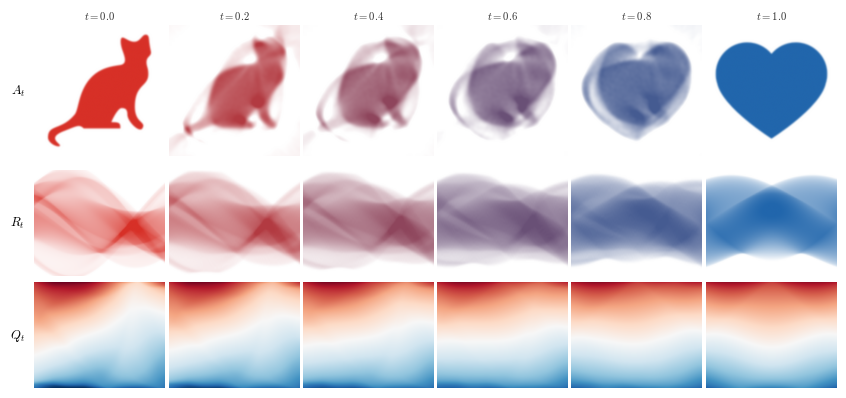

In [4]:
def tint_cmap(color):
    """Return tint colormap for the current computation."""
    return LinearSegmentedColormap.from_list("tint", [(1, 1, 1), color])


def display_density(a, *, endpoint=False):
    """Evaluate the display density on the current grid."""
    b = np.asarray(a, dtype=float).copy()
    if not endpoint:
        b = np.maximum(b - np.percentile(b[b > 0], 10.0), 0.0) if np.any(b > 0) else b
        b = gaussian_filter(b, sigma=0.20, mode="constant")
    return b

q_abs = max(abs(np.min(Q0)), abs(np.max(Q0)), abs(np.min(Q1)), abs(np.max(Q1)))
fig, axes = plt.subplots(
    3,
    len(T_VALUES),
    figsize=(10.35, 4.82),
    gridspec_kw={"height_ratios": [1.0, 0.72, 0.72], "hspace": 0.052, "wspace": 0.026},
)

for j, t in enumerate(T_VALUES):
    color = interp_color(float(t), RED, BLUE)
    cmap_density = tint_cmap(color)

    ax = axes[0, j]
    endpoint = np.isclose(t, 0.0) or np.isclose(t, 1.0)
    im = display_density(A_panels[j], endpoint=endpoint)[SLY, SLX]
    vmax = np.percentile(im[im > 0], 98.3) if np.any(im > 0) else 1.0
    ax.imshow(im, cmap=cmap_density, origin="lower", interpolation="bicubic", vmin=0.0, vmax=vmax)
    remove_axes(ax)

    ax = axes[1, j]
    sino = R_panels[j]
    rvmax = np.percentile(sino, 99.0)
    ax.imshow(sino, cmap=cmap_density, origin="lower", aspect="auto", interpolation="bilinear", vmin=0.0, vmax=rvmax)
    remove_axes(ax)

    ax = axes[2, j]
    # Display a light smoothing of Q_t only for readability; reconstruction uses the unsmoothed quantiles.
    q_show = gaussian_filter(Q_panels[j], sigma=(0.32, 0.0))
    ax.imshow(q_show, cmap="RdBu_r", origin="lower", aspect="auto", interpolation="bilinear", vmin=-q_abs, vmax=q_abs)
    remove_axes(ax)

row_labels = [r"$A_t$", r"$R_t$", r"$Q_t$"]
for i, label in enumerate(row_labels):
    axes[i, 0].text(-0.072, 0.5, label, transform=axes[i, 0].transAxes, ha="right", va="center", fontsize=9.2)
for j, t in enumerate(T_VALUES):
    axes[0, j].text(0.5, 1.028, rf"$t={t:.1f}$", transform=axes[0, j].transAxes, ha="center", va="bottom", fontsize=7.7, color="#303030")

save_pdf(fig, OUT / "grid.pdf", pad_inches=0.016)
fig.savefig(OUT / "grid.png", dpi=220, bbox_inches="tight", pad_inches=0.016)
THUMB.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(THUMB, dpi=155, bbox_inches="tight", pad_inches=0.016)
plt.show()


## Sanity checks

The endpoint densities are the input silhouettes.  The endpoint sinograms are direct Radon transforms, while the intermediate sinograms are obtained by quantile interpolation.  The reconstructed intermediate densities are nonnegative and normalized after filtered back-projection.

In [5]:
def centered_correlation(a, b):
    """Return centered correlation for the current computation."""
    aa = np.asarray(a, dtype=float).ravel() - np.mean(a)
    bb = np.asarray(b, dtype=float).ravel() - np.mean(b)
    return float(aa @ bb / (np.linalg.norm(aa) * np.linalg.norm(bb)))

cat_reconstruction = filtered_back_projection(R0)
log(f"endpoint masses: {A_panels[0].sum():.6f}, {A_panels[-1].sum():.6f}")
log("intermediate masses:", [round(float(a.sum()), 6) for a in A_panels[1:-1]])
log(
    "cat FBP orientation check:",
    f"upright={centered_correlation(cat_reconstruction, alpha0):.4f}",
    f"vertical-flip={centered_correlation(cat_reconstruction, np.flipud(alpha0)):.4f}",
)
log("saved", OUT / "grid.pdf")


endpoint masses: 1.000000, 1.000000
intermediate masses: [1.0, 1.0, 1.0, 1.0]
cat FBP orientation check: upright=0.9852 vertical-flip=0.4009
saved /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/sliced-radon-barycenter/grid.pdf
